In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as ss
import pickle
import os
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from rdkit.Chem import Draw

plt.rcParams['figure.dpi'] = 300

In [2]:
# Define some paths
root = '.'
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/scripts'
PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

In [3]:
DOCKING_RESULTS = {}

# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS))):

    try:

        # Get scores
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS, pocket, 'report.csv'))

        # Save results
        DOCKING_RESULTS[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

    except:
        pass

100%|██████████| 276/276 [02:18<00:00,  2.00it/s]


In [4]:
# Sort pockets by median
pockets = sorted(DOCKING_RESULTS)
medians = [np.median(list(DOCKING_RESULTS[p].values())) for p in pockets]
ind = np.argsort(medians)
pockets = np.array(pockets)[ind]

In [5]:
# Read models results
MODELS_RESULTS = {}
root = '/aloy/home/acomajuncosa/Ersilia/mtb/processed/unidock_docking/models/'
bins = ["bin_01", 'bin_05', 'bin_1']
for pocket in tqdm(pockets):
    MODELS_RESULTS[pocket] = {}
    for b in bins:
        aurocs = open(os.path.join(root, pocket, b, "AUROCs.csv")).readlines()[0].split(",")
        MODELS_RESULTS[pocket][b] = np.array(aurocs, dtype=float)

100%|██████████| 276/276 [00:29<00:00,  9.23it/s]


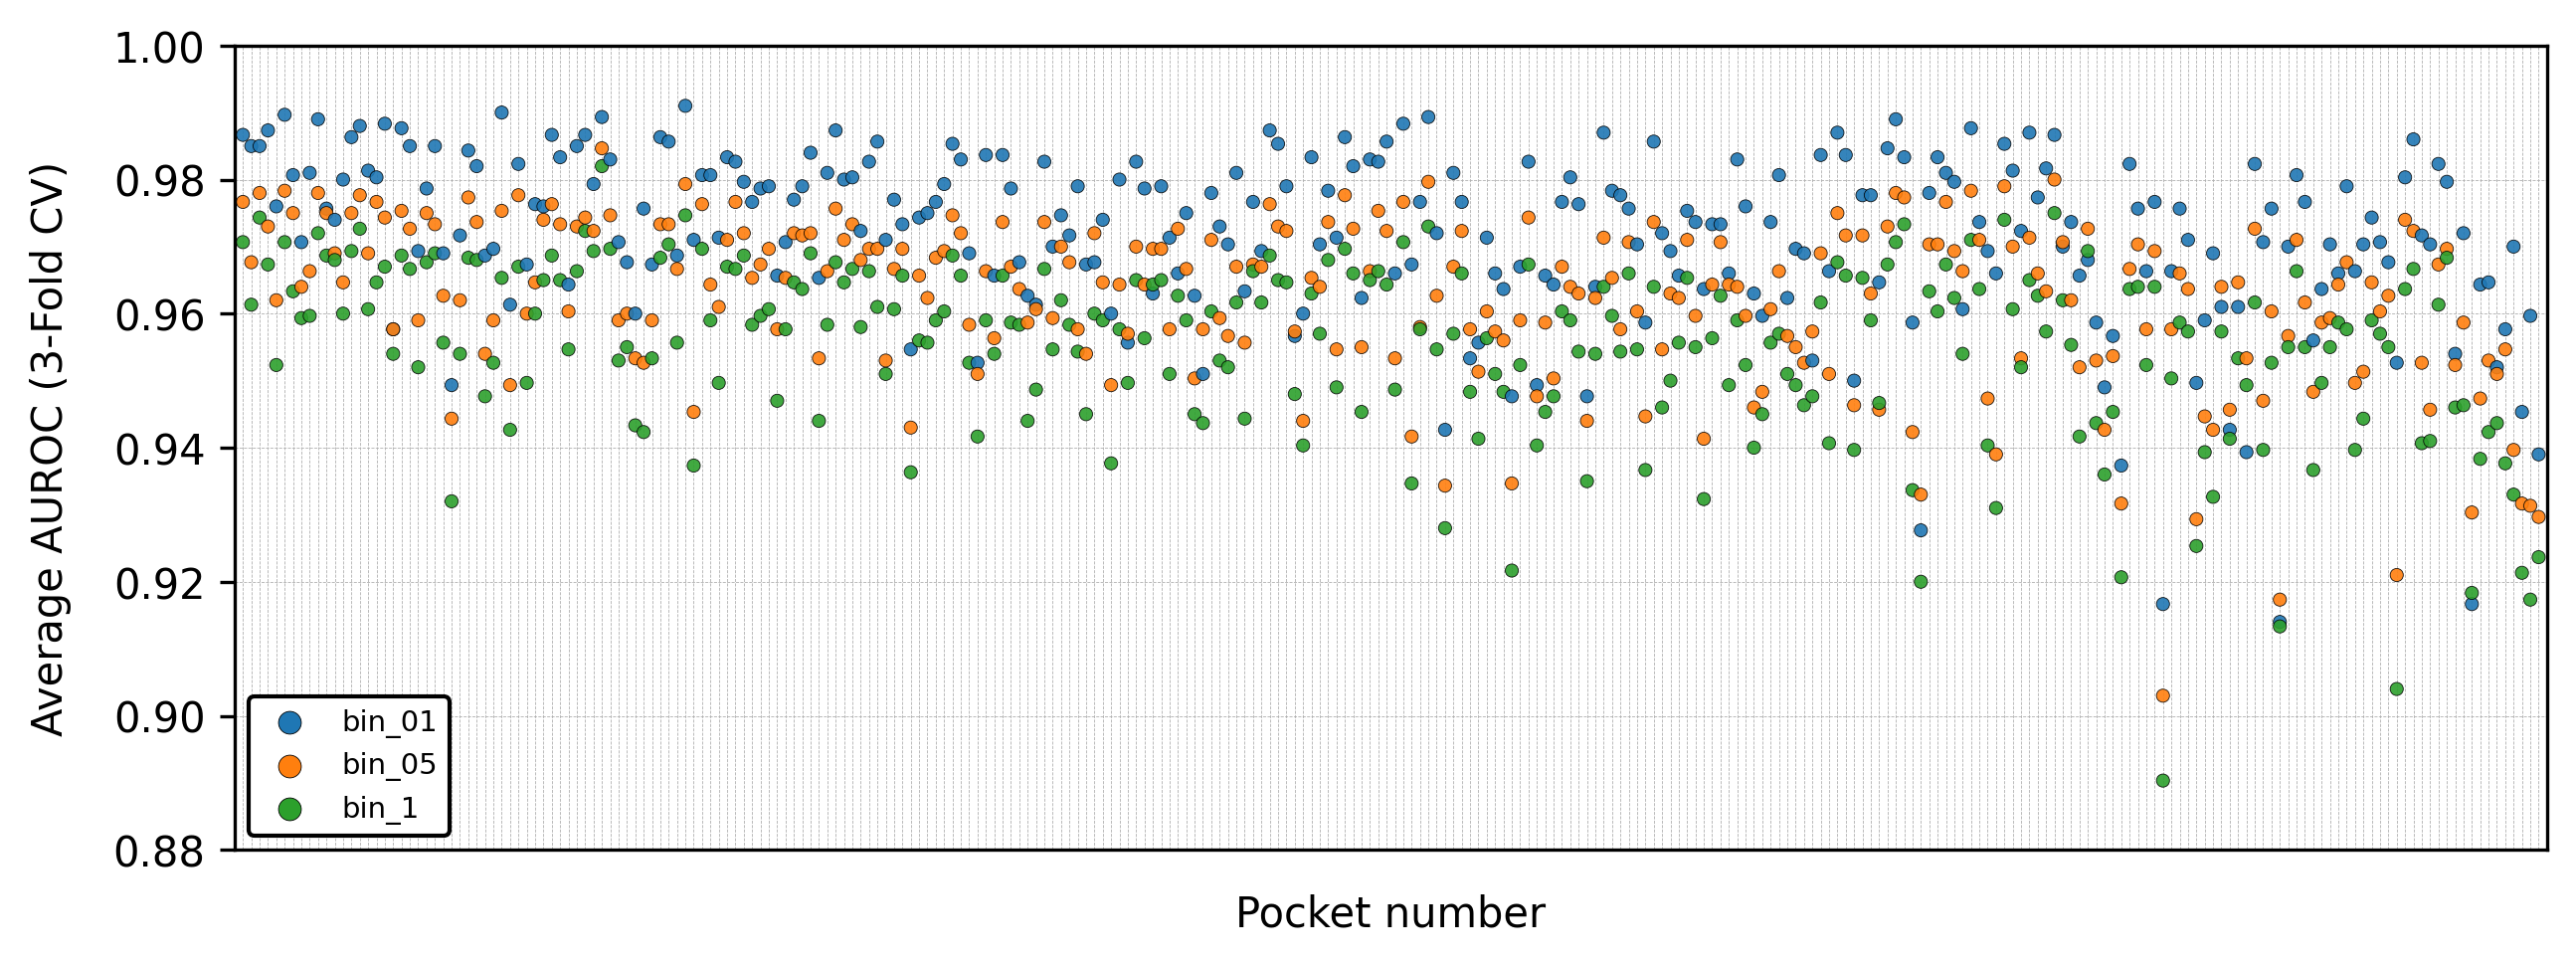

In [6]:
x, y = [], []
colors_ = ['#1f77b4', '#ff7f0e', '#2ca02c']
colors = []
for c, pocket in enumerate(pockets):
    for c2, b in enumerate(bins):
        x.append(c)
        y.append(np.average(MODELS_RESULTS[pocket][b]))
        colors.append(colors_[c2])

fig, ax = plt.subplots(figsize=(10, 3.5))

plt.xlim([-1, max(x) + 1])
plt.scatter(x, y, s=10, c=colors, alpha=0.9, edgecolor='black', linewidth=0.2, zorder=2)
plt.xticks([i for i in range(len(pockets))], ["" for i in range(len(pockets))])
plt.tick_params(axis='x', length=0)
plt.ylim([0.88, 1.00])
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("Average AUROC (3-Fold CV)", labelpad=10)


# Create dummy scatters for legend
legend_scatter = []
for c2, b in enumerate(bins):
    legend_scatter.append(
        ax.scatter([], [], s=30, color=colors_[c2], 
                   edgecolor='black', linewidth=0.2, label=b))
    ax.legend(handles=legend_scatter, loc="lower left", fontsize=7, edgecolor='k', framealpha=1)
plt.show()


In [11]:
MODELS_RESULTS['alphafold2_P9WFS9_model_0_pocket_1']

{'bin_01': array([0.988, 0.984, 0.974]),
 'bin_05': array([0.973, 0.975, 0.973]),
 'bin_1': array([0.969, 0.97 , 0.965])}

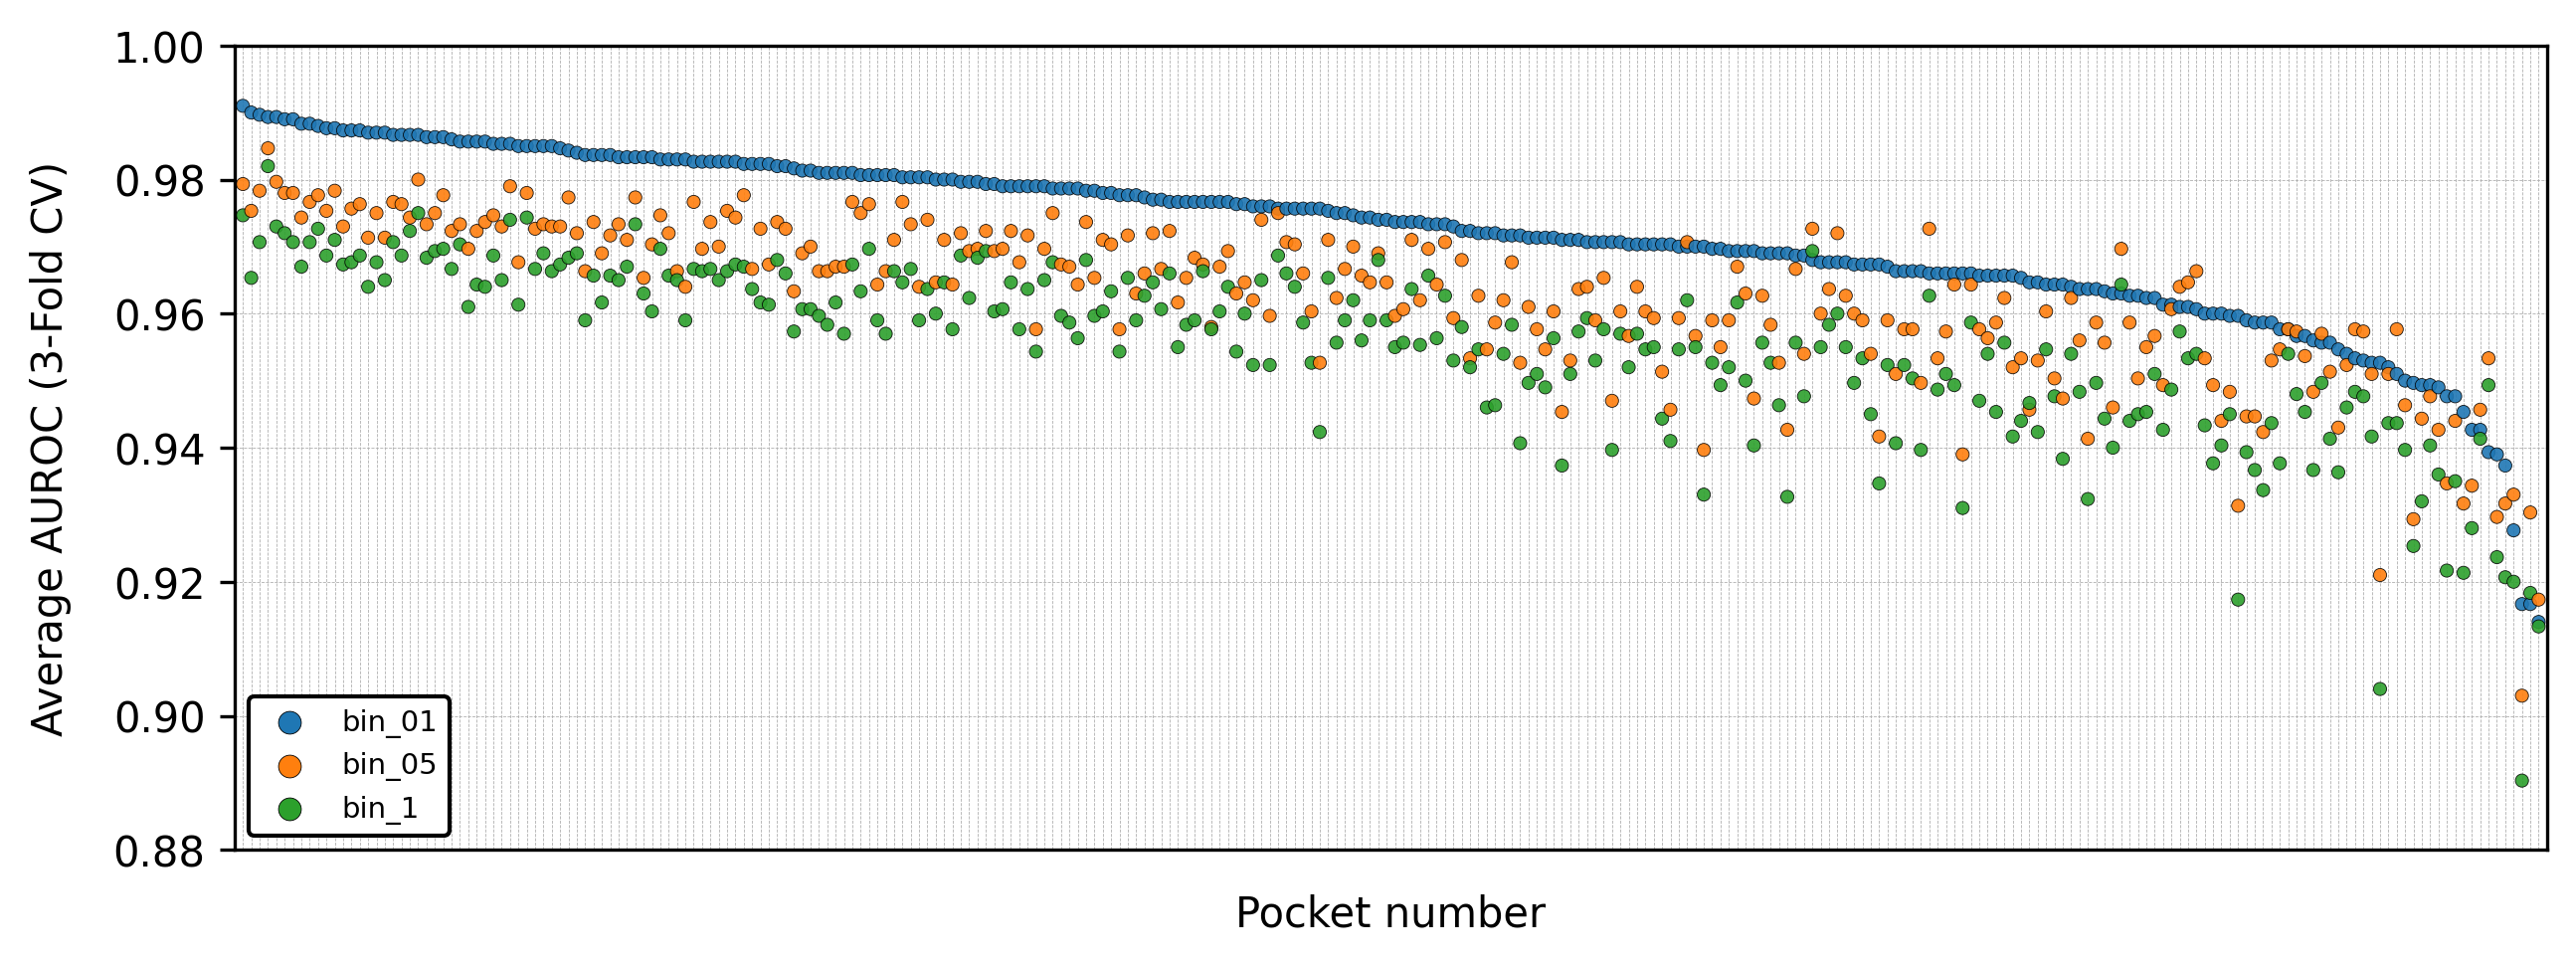

In [13]:
pockets_sorted = sorted(pockets, key = lambda x: np.average(MODELS_RESULTS[x]['bin_01']), reverse=True)
x, y = [], []
colors_ = ['#1f77b4', '#ff7f0e', '#2ca02c']
colors = []
for c, pocket in enumerate(pockets_sorted):
    for c2, b in enumerate(bins):
        x.append(c)
        y.append(np.average(MODELS_RESULTS[pocket][b]))
        colors.append(colors_[c2])

fig, ax = plt.subplots(figsize=(10, 3.5))

plt.xlim([-1, max(x) + 1])
plt.scatter(x, y, s=10, c=colors, alpha=0.9, edgecolor='black', linewidth=0.2, zorder=2)
plt.xticks([i for i in range(len(pockets))], ["" for i in range(len(pockets))])
plt.tick_params(axis='x', length=0)
plt.ylim([0.88, 1.00])
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("Average AUROC (3-Fold CV)", labelpad=10)


# Create dummy scatters for legend
legend_scatter = []
for c2, b in enumerate(bins):
    legend_scatter.append(
        ax.scatter([], [], s=30, color=colors_[c2], 
                   edgecolor='black', linewidth=0.2, label=b))
    ax.legend(handles=legend_scatter, loc="lower left", fontsize=7, edgecolor='k', framealpha=1)
plt.show()


In [7]:
# # Creating a pickle only for the bin_01 models
# p = pickle.load(open(os.path.join("../processed/unidock_docking/pickle.pkl"), "rb"))

# # Filter only bins 01
# p = [i for i in p if i[1] == 'bin_01']
# pickle.dump(p, open(os.path.join("../processed/unidock_docking/pickle_bins_01.pkl"), "wb"))